Code created by: Lorena Espinosa, Johana Rátiva, Eduards Chipatecua 

Class: Procesamiento del Lenguaje Natural

University: Universidad de los Andes

Date: October 10, 2026

Un embedding representa cada palabra mediante un vector numérico. Estos vectores permiten estudiar las relaciones entre palabras utilizando operaciones matemáticas.

In [1]:
import io
import random


import contextlib
import gzip
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.decomposition import PCA

from tensorflow import keras

from scipy.stats import spearmanr
from scipy.stats import pearsonr

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

I0000 00:00:1791691836.445985  160395 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791691836.446402  160395 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791691836.481717  160395 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791691837.740906  160395 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

# Seleccicón de Palabras 
computer, chocolate, happiness, forest, elephant, doctor, football, guitar, airplane, money

In [2]:
GLOVE_FILENAME = "glove-wiki-gigaword-50.gz"

GLOVE_URL = (
    "https://github.com/RaRe-Technologies/gensim-data/releases/"
    "download/glove-wiki-gigaword-50/"
    f"{GLOVE_FILENAME}"
)

with contextlib.redirect_stdout(io.StringIO()):
    glove_path = keras.utils.get_file(
        fname=GLOVE_FILENAME,
        origin=GLOVE_URL,
        cache_subdir="datasets",
    )


def load_glove_vectors(path):
    """Carga vectores en formato Word2Vec comprimido."""
    with gzip.open(path, "rt", encoding="utf-8") as file:
        number_of_words, vector_size = map(int, next(file).split())
        words = []
        vectors = np.empty((number_of_words, vector_size),dtype=np.float32,)

        for index, line in enumerate(file):
            word, values = line.rstrip().split(maxsplit=1)
            words.append(word)
            vectors[index] = np.fromstring(
                values,
                sep=" ",
                dtype=np.float32,
            )

    word_to_index = {
        word: index for index, word in enumerate(words)
    }
    vector_norms = np.linalg.norm(vectors, axis=1)
    return words, vectors, word_to_index, vector_norms


(glove_words,glove_values,glove_index,glove_norms,) = load_glove_vectors(glove_path)

def most_similar_glove(query_word, top_n=5):
    """Busca vecinos mediante similitud coseno en GloVe."""
    query_index = glove_index[query_word]
    query_vector = glove_values[query_index]
    denominator = np.maximum( glove_norms * np.linalg.norm(query_vector), 1e-12,)
    similarities = glove_values @ query_vector / denominator
    candidate_indices = np.argpartition(similarities,-(top_n + 1),)[-(top_n + 1):]
    
    ranked_indices = candidate_indices[
        np.argsort(similarities[candidate_indices])[::-1]
    ]

    return [
        (glove_words[index], float(similarities[index]))
        for index in ranked_indices
        if index != query_index
    ][:top_n]

In [3]:
results = []
selected_words = [
    "computer",
    "chocolate",
    "happiness",
    "forest",
    "elephant",
    "doctor",
    "football",
    "guitar",
    "airplane",
    "money",
]
for word in selected_words:
    if word in glove_words:
        vecinos = most_similar_glove(word)
        for vecino, similarity in vecinos:
            results.append({
                "Palabra original": word,
                "Palabra cercana": vecino,
                "Similitud coseno": similarity,
            })

  
results_df = pd.DataFrame(results)   


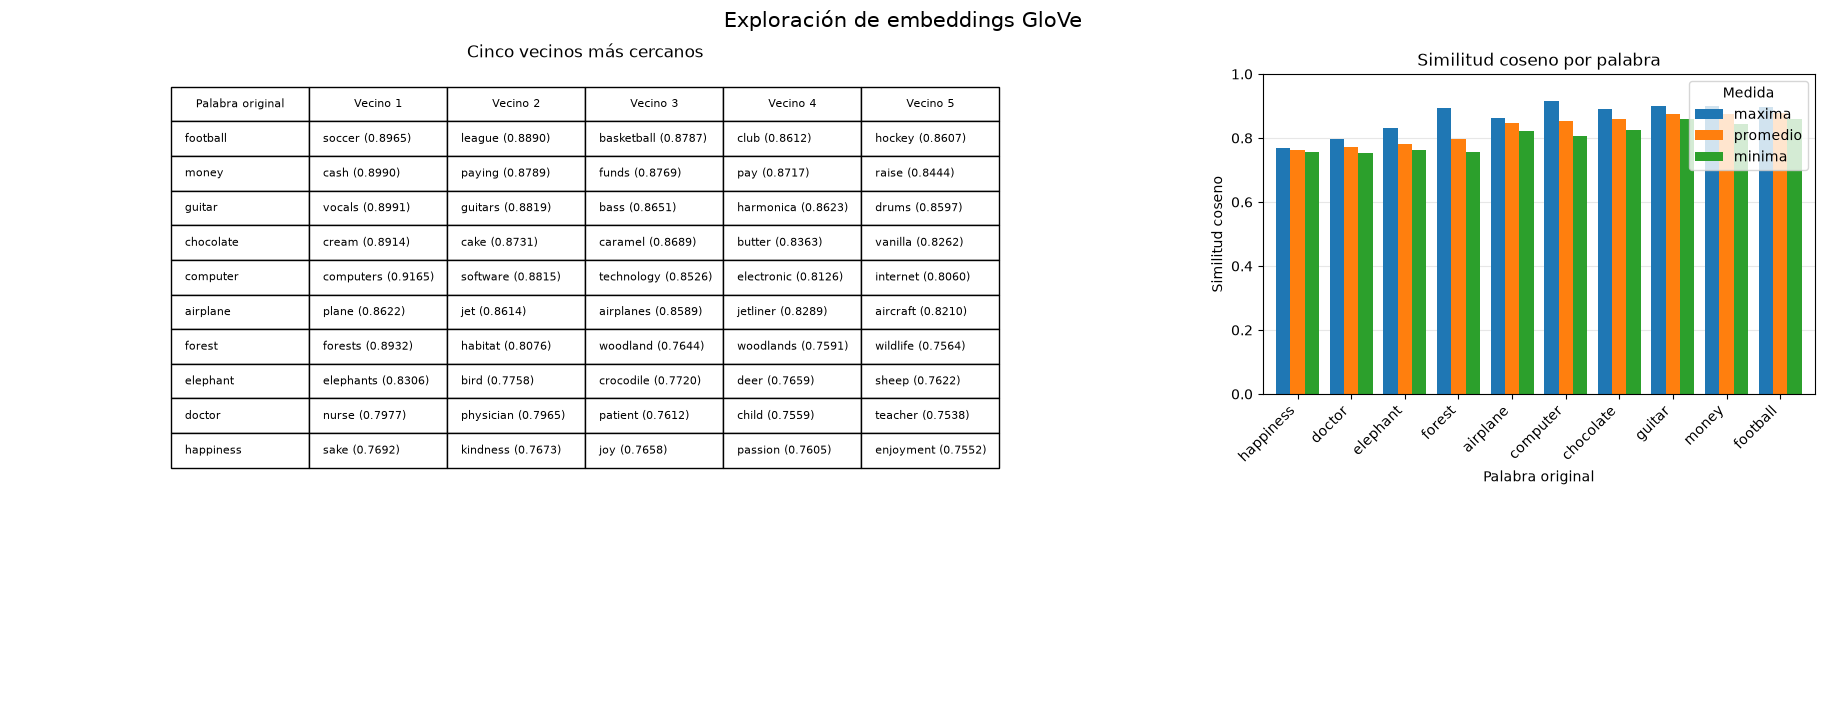

In [4]:
# 1. Preparar la tabla de vecinos
table_df = results_df.copy()

table_df["Vecino"] = (
    table_df["Palabra cercana"]
    + " ("
    + table_df["Similitud coseno"].map(lambda x: f"{x:.4f}")
    + ")"
)

table_df["Posición"] = (
    table_df.groupby("Palabra original").cumcount() + 1
)

table_df = (
    table_df
    .pivot(
        index="Palabra original",
        columns="Posición",
        values="Vecino",
    )
    .rename(columns={
        1: "Vecino 1",
        2: "Vecino 2",
        3: "Vecino 3",
        4: "Vecino 4",
        5: "Vecino 5",
    })
    .reset_index()
)

table_df.columns.name = None


# 2. Calcular las estadísticas
summary_df = (
    results_df
    .groupby("Palabra original")["Similitud coseno"]
    .agg(
        maxima="max",
        promedio="mean",
        minima="min",
    )
    .round(4)
    .sort_values("promedio", ascending=False)
)

# Utilizar el mismo orden en ambos paneles
word_order = summary_df.index.tolist()

table_df = (
    table_df
    .set_index("Palabra original")
    .loc[word_order]
    .reset_index()
)

summary_df = summary_df.sort_values("promedio")


# 3. Crear una figura con dos paneles
fig, (ax_table, ax_chart) = plt.subplots(
    ncols=2,
    figsize=(19, 8),
    gridspec_kw={"width_ratios": [2.5, 1.2]},
)

# Panel izquierdo: tabla
ax_table.axis("off")

table = ax_table.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    cellLoc="left",
    colLoc="center",
    colWidths=[0.12, 0.12, 0.12, 0.12, 0.12, 0.12],
    loc="upper center",
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 2)

ax_table.set_title("Cinco vecinos más cercanos",pad=12)


# Panel derecho: gráfico
summary_df.plot(
    kind="bar",
    ax=ax_chart,
    width=0.8,
)

ax_chart.set_title("Similitud coseno por palabra")
ax_chart.set_xlabel("Palabra original")
ax_chart.set_ylabel("Similitud coseno")
ax_chart.set_ylim(0, 1)
ax_chart.legend(title="Medida")
ax_chart.grid(axis="y", alpha=0.3)
ax_chart.set_axisbelow(True)

plt.setp(
    ax_chart.get_xticklabels(),
    rotation=45,
    ha="right",
)


# 4. Ajustar la figura
fig.suptitle(
    "Exploración de embeddings GloVe",
    fontsize=15,
)

fig.subplots_adjust(
    left=0.03,
    right=0.98,
    top=0.90,
    bottom=0.10,
    wspace=0.12,
)
# Reducir la altura del gráfico manteniendo alineado el borde superior
pos = ax_chart.get_position()

new_height = pos.height * 0.5
new_y = pos.y0 + pos.height - new_height

ax_chart.set_position([
    pos.x0,
    new_y,
    pos.width,
    new_height,
])

plt.show()

Los resultados de GloVe permiten observar que las palabras mas cercanas presentan relaciones morfologicas, semanticas o contextuales. Se pueden destacar tres patrones principales:
- Relaciones morfologicas: algunas palabras tienen como vecino mas cercano una variacion de su forma, como computer–computers, forest–forests y elephant–elephants. Estas parejas alcanzan similitudes coseno de 0.9165, 0.8932 y 0.8306, respectivamente.
- Similitud semantica: se encuentran palabras con significados relacionados, como airplane–aircraft y happiness–joy, aunque estar cerca en el espacio vectorial no significa que sean sinonimos exactos.
- Asociaciones contextuales: el modelo tambien relaciona palabras que suelen aparecer en contextos similares. Por ejemplo, doctor se asocia con nurse y patient, mientras que football se relaciona con league y club.

# Proyección las palabras seleccionadas

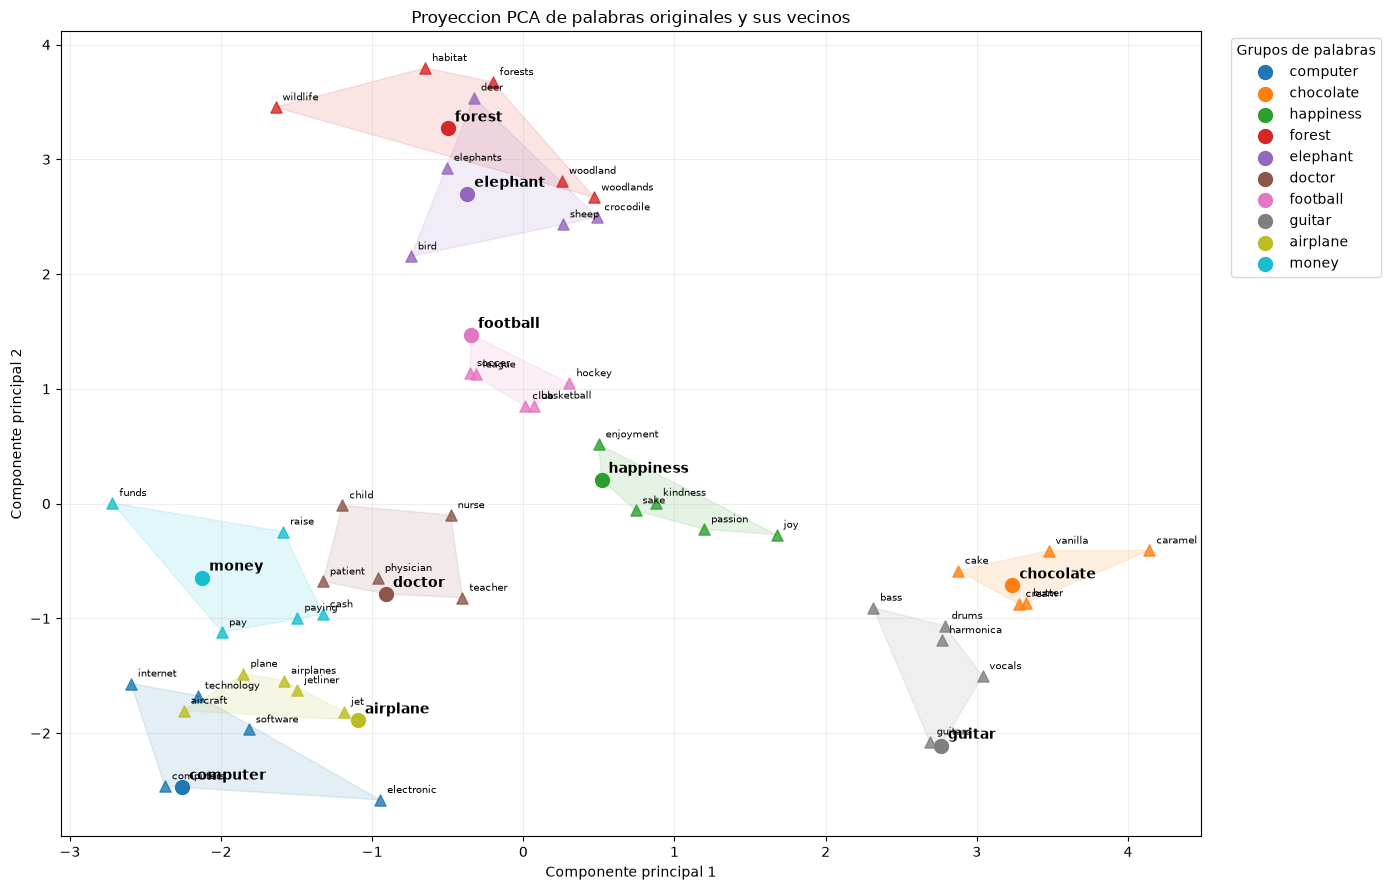

In [5]:
from scipy.spatial import ConvexHull

# Obtener las palabras originales desde results_df
original_words = results_df["Palabra original"].drop_duplicates().tolist()

# Construir los grupos de vecinos desde results_df
neighbor_groups = {
    word: results_df.loc[
        results_df["Palabra original"] == word,
        "Palabra cercana",
    ].tolist()
    for word in original_words
}

# Asignar cada vecino a un solo grupo para evitar duplicados
original_set = set(original_words)
grupo_vecinos = {}

for word in original_words:
    for neighbor in neighbor_groups[word]:
        if neighbor not in original_set and neighbor not in grupo_vecinos:
            grupo_vecinos[neighbor] = word

# Combinar las palabras que se van a representar
lista_vecinos = list(grupo_vecinos.keys())
all_words = original_words + lista_vecinos

# Obtener los vectores GloVe
word_vectors = np.array([
    glove_values[glove_index[word]]
    for word in all_words
])

# Reducir los vectores a dos dimensiones mediante PCA
coordinates = PCA(
    n_components=2,
    random_state=SEED,
).fit_transform(word_vectors)

coordinates_by_word = {
    word: coordinate
    for word, coordinate in zip(all_words, coordinates)
}

# Crear la visualización
fig, ax = plt.subplots(figsize=(14, 9))
colors = plt.get_cmap("tab10").colors

for index, word in enumerate(original_words):
    color = colors[index % len(colors)]

    # Obtener las coordenadas de la palabra original y sus vecinos
    group_words = [
        neighbor
        for neighbor in neighbor_groups[word]
        if grupo_vecinos.get(neighbor) == word
    ]

    group_coordinates = np.array([
        coordinates_by_word[word],
        *[coordinates_by_word[neighbor] for neighbor in group_words],
    ])

    # Dibujar la región sombreada del grupo
    if len(group_coordinates) >= 3:
        hull = ConvexHull(group_coordinates)

        ax.fill(
            group_coordinates[hull.vertices, 0],
            group_coordinates[hull.vertices, 1],
            color=color,
            alpha=0.12,
            zorder=1,
        )

    # Dibujar la palabra original
    x_coordinate, y_coordinate = coordinates_by_word[word]

    ax.scatter(
        x_coordinate,
        y_coordinate,
        color=color,
        marker="o",
        s=100,
        label=word,
        zorder=3,
    )

    ax.annotate(
        word,
        (x_coordinate, y_coordinate),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
    )

    # Dibujar los vecinos del grupo con el mismo color
    for neighbor in group_words:
        x_coordinate, y_coordinate = coordinates_by_word[neighbor]

        ax.scatter(
            x_coordinate,
            y_coordinate,
            color=color,
            marker="^",
            s=65,
            alpha=0.8,
            zorder=2,
        )

        ax.annotate(
            neighbor,
            (x_coordinate, y_coordinate),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=7,
        )

ax.set_title("Proyeccion PCA de palabras originales y sus vecinos")
ax.set_xlabel("Componente principal 1")
ax.set_ylabel("Componente principal 2")
ax.legend(
    title="Grupos de palabras",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# wordsim353crowd

In [6]:
wordsim_df = pd.read_csv("wordsim353crowd.csv")
display(wordsim_df.head())

def cosine_similarity_glove(p1, p2):
    """Calcula la similitud coseno entre dos palabras de GloVe."""

    if p1 not in glove_index or p2 not in glove_index:
        return np.nan

    index1 = glove_index[p1]
    index2 = glove_index[p2]

    vector1 = glove_values[index1]
    vector2 = glove_values[index2]

    denominator = glove_norms[index1] * glove_norms[index2]

    if denominator == 0:
        return np.nan
    return np.dot(vector1, vector2) / denominator

,Word 1,Word 2,Human (Mean)
0,admission,ticket,5.5360
1,alcohol,chemistry,4.1250
2,aluminum,metal,6.6250
3,announcement,effort,2.0625
4,announcement,news,7.1875


In [7]:
wordsim_df["Cosine Similarity"] = wordsim_df.apply(
    lambda row: cosine_similarity_glove(row["Word 1"],row["Word 2"]),
    axis=1
)

display(wordsim_df.head())

,Word 1,Word 2,Human (Mean),Cosine Similarity
0,admission,ticket,5.5360,0.482149
1,alcohol,chemistry,4.1250,0.361794
2,aluminum,metal,6.6250,0.732865
3,announcement,effort,2.0625,0.514945
4,announcement,news,7.1875,0.686600


In [8]:
missing_words = set()

for column in ["Word 1", "Word 2"]:
    missing_words.update(
        word
        for word in wordsim_df[column].unique()
        if word not in glove_index
    )

print("Total de parejas:", len(wordsim_df))
print("Parejas con similitud calculada:",
      wordsim_df["Cosine Similarity"].notna().sum())
print("Parejas sin similitud calculada:",
      wordsim_df["Cosine Similarity"].isna().sum())
print("Palabras fuera del vocabulario:", len(missing_words))
print("Palabras no encontradas:", sorted(missing_words))

Total de parejas: 353
Parejas con similitud calculada: 335
Parejas sin similitud calculada: 18
Palabras fuera del vocabulario: 18
Palabras no encontradas: ['American', 'Arafat', 'Brazil', 'CD', 'FBI', 'Freud', 'Harvard', 'Israel', 'Jackson', 'Japanese', 'Jerusalem', 'Maradona', 'Mars', 'Mexico', 'OPEC', 'Palestinian', 'Wednesday', 'Yale']


## Correlación de Spearman

La correlación de Spearman mide el grado de asociación entre dos variables a partir de sus rangos. Es conveniente utilizarla porque permite comparar el orden de las parejas según la similitud coseno de GloVe y las valoraciones humanas, sin exigir que ambas medidas tengan una relación lineal.

In [9]:
#Utilizo un dataset cuya similitu coseno sea valida
wordsim_valid = wordsim_df.dropna(
    subset=["Cosine Similarity", "Human (Mean)"]
).copy()


correlation, p_value = spearmanr(
    wordsim_valid["Cosine Similarity"],
    wordsim_valid["Human (Mean)"]
)

print("Correlación de Spearman:", correlation)
print("Valor p:", p_value)

Correlación de Spearman: 0.45527727945955065
Valor p: 1.5169716787890739e-18


0.45 indica que las parejas de palabras que reciben valoraciones humanas más altas tienden a presentar también similitudes coseno más altas en GloVe.Sin embargo, la relación no es perfecta. El modelo no reproduce completamente el orden de las parejas establecido por los anotadores.Esto puede ser dado a que los anotadores tienen como regla que se deben considerar similares aquellas palabras que pertenezcan al mismo dominio/contexto coceptual

## Correlación de Pearson

La correlación de Pearson permite identificar si existe una relación lineal entre dos variables y si ambas aumentan o disminuyen de manera similar. En este experimento, es conveniente porque permite analizar si las parejas de palabras que reciben puntuaciones más altas por parte de las personas también obtienen una mayor similitud coseno con GloVe.

In [10]:
correlation_pearson, p_value_pearson = pearsonr(
    wordsim_valid["Cosine Similarity"],
    wordsim_valid["Human (Mean)"]
)

print("Correlación de Pearson:", correlation_pearson)
print("Valor p:", p_value_pearson)

Correlación de Pearson: 0.4397257311268302
Valor p: 2.846122239769645e-17


El 0.43 obtenido indica que cuando las personas consideran que dos palabras están más relacionadas, sus vectores tienden a tener una mayor similitud coseno, es decir, apuntan en direcciones más parecidas dentro del espacio vectorial.